In [1]:

import pandas as pd
import numpy as np
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


In [3]:
# 1. Load CSV

df = pd.read_csv("quora_questions.csv")   

df = df.dropna(subset=["Question"])  
df

,Question
0,What is the step by step guide to invest in sh...
1,What is the story of Kohinoor (Koh-i-Noor) Dia...
2,How can I increase the speed of my internet co...
3,Why am I mentally very lonely? How can I solve...
4,"Which one dissolve in water quikly sugar, salt..."
...,...
404284,How many keywords are there in the Racket prog...
404285,Do you believe there is life after death?
404286,What is one coin?
404287,What is the approx annual cost of living while...


In [4]:

# 2. Text Cleaning

nltk.download('stopwords')

stop_words = set(nltk.corpus.stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nvgra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]', ' ', text)
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

df["clean"] = df["Question"].apply(clean_text)


In [6]:

# 3. TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean"])


In [7]:
X

<404289x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 1777139 stored elements in Compressed Sparse Row format>

In [8]:

# 4. LSA (TruncatedSVD)
n_topics = 10     

lsa = TruncatedSVD(n_components=n_topics, random_state=42)
lsa_topics = lsa.fit_transform(X)


In [9]:

# 5. Extract Top Words per Topic
terms = tfidf.get_feature_names_out()

for i, comp in enumerate(lsa.components_):
    terms_in_topic = zip(terms, comp)
    sorted_terms = sorted(terms_in_topic, key=lambda x: x[1], reverse=True)[:10]
    
    print(f"\n Topic {i+1}:")
    print(" ".join([t[0] for t in sorted_terms]))



 Topic 1:
best way india learn get money make online books book

 Topic 2:
get people quora like make money good difference india questions

 Topic 3:
difference best love programming language engineering science examples computer data

 Topic 4:
get rid job pregnant best sydney traffic back acne period

 Topic 5:
quora people like questions question ask think many know best

 Topic 6:
like life india feel good would work know sex first

 Topic 7:
india good trump donald people think president pakistan clinton become

 Topic 8:
good learn life english way people become improve language know

 Topic 9:
life people love know think would trump donald one purpose

 Topic 10:
life quora india mean question purpose english meaning improve questions


In [10]:
# 6. Assign topic to each question

df["Topic"] = np.argmax(lsa_topics, axis=1)


In [11]:
df["Topic"] 

0         6
1         7
2         1
3         1
4         1
         ..
404284    7
404285    9
404286    1
404287    1
404288    5
Name: Topic, Length: 404289, dtype: int64

In [12]:

df.to_csv("lsa_output.csv", index=False)

print("\nSaved: lsa_output.csv")



Saved: lsa_output.csv


# find best number of topics

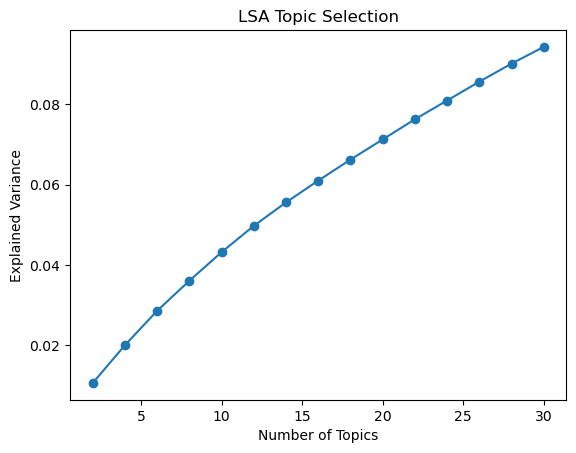

In [28]:
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

variance = []
topic_range = range(2, 31, 2)  

for n in topic_range:
    svd = TruncatedSVD(n_components=n)
    svd.fit(X)
    variance.append(svd.explained_variance_ratio_.sum())

plt.plot(topic_range, variance, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Explained Variance")
plt.title("LSA Topic Selection")
plt.show()



The curve increases sharply at first

Then slows down → elbow point = best number of topics


Example:

    If variance rises up to 0.75 with 10 topics
    
    But only to 0.78 with 20 topics → 10 is best

Use explained variance:

    Plot variance vs. topics
    
    Pick the elbow point

Most common optimal range: 10–20 topics for medium datasets.